In [10]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [11]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.01036522 0.26050698 0.26765607 ... 0.04702075 0.1928855  0.09331249]
 [0.03511864 0.88262983 0.90685184 ... 0.15931211 0.6535199  0.31615424]
 [0.00324297 0.08150491 0.08374165 ... 0.0147114  0.06034816 0.02919471]
 ...
 [0.02483507 0.62417487 0.6413041  ... 0.11266175 0.46215376 0.22357677]
 [0.03514081 0.88318708 0.90742438 ... 0.1594127  0.6539325  0.31635384]
 [0.00857332 0.21547158 0.22138476 ... 0.03889199 0.15954023 0.077181  ]]

Noisy Matrix (with Homoscedastic Noise):
[[ 1.57424604e-01  2.39870355e-01  3.63723247e-01 ... -6.93458294e-05
   2.40432807e-01  1.08591891e-01]
 [ 1.21745690e-02  7.98900862e-01  8.44048312e-01 ...  8.57462448e-03
   6.96954647e-01  2.85643118e-01]
 [ 3.50102409e-02  7.47560592e-02 -6.49443548e-03 ... -3.68620597e-02
  -4.09132136e-02  1.41409587e-02]
 ...
 [ 2.67094545e-02  6.74572234e-01  4.25824444e-01 ...  2.13725945e-01
   5.73797723e-01  1.52265124e-01]
 [ 1.22820754e-02  8.33624264e-01  7.52968551e-01 ...  3.8

In [12]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF
import numpy as np

In [13]:
results =[]
for i in range(100):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix, prior_F="laplace",
                      prior_L="laplace") 
    mycebmf.initialise_factors()

    mycebmf.fit()
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)
    results.append( rr)
    res= np.asarray(results)
    print(np.mean(res ))
    
 

0.002912263083610963
0.002426019000075455
0.0031239050215124534
0.002482162979502547
0.0028247219636655246
0.00256632398461923
0.00249947011791183
0.0023676038296357674
0.0026437261689572942
0.0026057043906994566
0.0026729889063347506
0.0027871336144989225
0.002638602424072082
0.0025641955235753506
0.002501068364821055
0.002390965794674083
0.0022828068451087764
0.002212353471614985
0.0021091455481093368
0.0021130032027497927
0.002053099385454698
0.0020649398520961623
0.0021374460062728536
0.002116033733149985
0.0021180914024285635
0.002092763333268782
0.0021599260716836407
0.002251953968802754
0.0022207416708884408
0.0022483393044438
0.0022394463304160586
0.002251878061442336
0.0022525628551356707
0.0022127493805736993
0.0022686214746746552
0.002253282676789087
0.0023363957300865813
0.002321152281280459
0.002278196527456209
0.0022670077957460226
0.0022200582582514927
0.0021857907984308964
0.0021722717417587615
0.0021554174599766477
0.0021192605635355862
0.002113096448297523
0.002138098

In [14]:
import numpy as np
import matplotlib.pyplot as plt

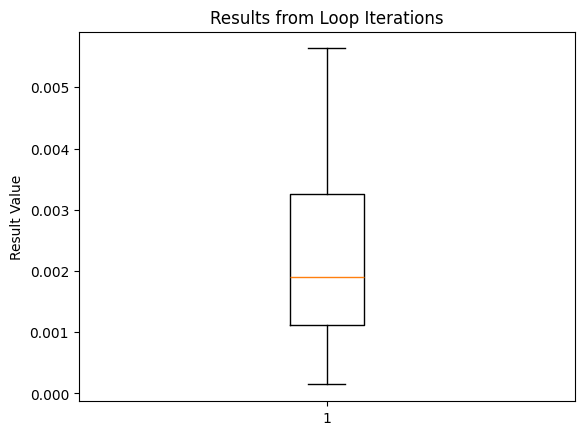

In [17]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [18]:
res= np.asarray(results)
np.mean(res )

np.float64(0.0022088637098990572)